In [197]:
import pandas as pd
import matplotlib.pyplot as plt

In [198]:
N_formigas = 40
N_iteracoes = 10

In [199]:
grafo = pd.read_csv('grafo1.csv', sep='\t')
grafo.head()

,origem,destino,custo
0,5,1,8.21
1,2,5,9.97
2,10,8,5.78
3,3,1,7.13
4,9,11,4.34


In [200]:
valor = grafo[['origem']].iat[0,0].item()
valor

5

Criando colunas Desejabilidade,feromonio e probabilidade para cada rota.

In [201]:
grafo[['desejabilidade', "feromonio",]] = 0 
grafo[['desejabilidade', "feromonio",]] = grafo[['desejabilidade', "feromonio",]].astype(float)
grafo.head()

,origem,destino,custo,desejabilidade,feromonio
0,5,1,8.21,0.0,0.0
1,2,5,9.97,0.0,0.0
2,10,8,5.78,0.0,0.0
3,3,1,7.13,0.0,0.0
4,9,11,4.34,0.0,0.0


Calculo desejabilidade (Menor caminho)

In [202]:
for i in grafo['custo']:
    grafo['desejabilidade'] = 1/grafo['custo']

grafo.head()

,origem,destino,custo,desejabilidade,feromonio
0,5,1,8.21,0.121803,0.0
1,2,5,9.97,0.100301,0.0
2,10,8,5.78,0.173010,0.0
3,3,1,7.13,0.140252,0.0
4,9,11,4.34,0.230415,0.0


Calculo feromonio 

In [203]:
grafo[['feromonio']] = 0.1
grafo.head()


,origem,destino,custo,desejabilidade,feromonio
0,5,1,8.21,0.121803,0.1
1,2,5,9.97,0.100301,0.1
2,10,8,5.78,0.173010,0.1
3,3,1,7.13,0.140252,0.1
4,9,11,4.34,0.230415,0.1


### Calculo da Probabilidade

In [ ]:
def probabilidade(grafo):
    valor = grafo["feromonio"] * grafo["desejabilidade"]
    grafo["probabilidade"] = valor / valor.sum()
    return grafo[['probabilidade']]


,origem,destino,custo,desejabilidade,feromonio,probabilidade
0,5,1,8.21,0.121803,0.1,0.019686
1,2,5,9.97,0.100301,0.1,0.016211
2,10,8,5.78,0.173010,0.1,0.027962
3,3,1,7.13,0.140252,0.1,0.022668
4,9,11,4.34,0.230415,0.1,0.037240


### Aualização do feromonio

In [205]:
def atualizar_feromonio(grafo,caminho_formiga):
    for i in range(len(caminho_formiga)-1):
        origem = caminho_formiga[i]
        destino = caminho_formiga[i+1]
        custo = grafo[(grafo['origem']==origem) & (grafo['destino']==destino)]['custo'].values[0]
        delta_feromonio = 1/custo
        grafo.loc[(grafo['origem']==origem) & (grafo['destino']==destino), 'feromonio'] += delta_feromonio

### Calculo do Custo do caminho gerado

In [206]:
def calcular_custo(grafo, caminho_formiga):
    custo_total = 0
    for i in range(len(caminho_formiga)-1):
        origem = caminho_formiga[i]
        destino = caminho_formiga[i+1]
        custo = grafo[(grafo['origem']==origem) & (grafo['destino']==destino)]['custo'].values[0]
        custo_total += custo
    return custo_total

### Evaporaçao do feromonio a cada epoca

In [207]:
def evaporar_feromonio(grafo, taxa_evaporacao=0.01):
    grafo['feromonio'] *= (1 - taxa_evaporacao)

### Feromonio ruim (nao atingiu o objetivo)

In [208]:
def atualizar_feromonio_ruim(grafo, caminho_formiga):
    for i in range(len(caminho_formiga)-1):
            origem = caminho_formiga[i]
            destino = caminho_formiga[i+1]
            grafo.loc[(grafo['origem']==origem) & (grafo['destino']==destino), 'feromonio'] -= 0.001
    

In [209]:
def calcular_media(matriz_formigas):
    media = matriz_formigas['custo'].mean()
    return media

### Funcao para iniciar 

In [210]:
def iniciar_formigas(grafo, N_formigas, meta):
    for i in range(N_formigas):
        caminho_formiga = []
        caminho_formiga.append(1)

        #BUSCA POR UM CAMINHO VALIDO PARA A FORMIGA
        while caminho_formiga[-1] != meta:
            
            vertice_atual = caminho_formiga[-1]
            opcoes = (grafo[grafo['origem']==vertice_atual])
            opcoes = opcoes[~opcoes["destino"].isin(caminho_formiga)] # Remove destinos que a formiga já visitou

            if opcoes.empty:
                # Se não houver opções e a formiga ainda não chegou à meta
                break

            escolha = opcoes.sample(n=1, weights='probabilidade', axis=0) # escolhe uma linha do grafo com base na probabilidade
            destino = escolha["destino"].iloc[0]
            caminho_formiga.append(destino)
        custo = calcular_custo(grafo,caminho_formiga)
        matriz_formigas.loc[len(matriz_formigas)] = [i,caminho_formiga,custo]
    media = calcular_media(matriz_formigas)
    return matriz_formigas,caminho_formiga,media


In [211]:
matriz_formigas = pd.DataFrame(columns=['formiga', 'caminho', 'custo'])
media = []
for i in range(N_iteracoes):
    matriz_formigas,caminho_formiga,media_epoca = iniciar_formigas(grafo, N_formigas,12)
    media.append(media_epoca)
    atualizar_feromonio(grafo, caminho_formiga)
    evaporar_feromonio(grafo)
    probabilidade(grafo)


Testes

In [212]:
matriz_formigas

,formiga,caminho,custo
0,0,"[1, 12]",8.66
1,1,"[1, 11, 8, 3, 6, 4, 9, 12]",35.30
2,2,"[1, 12]",8.66
3,3,"[1, 11, 12]",11.77
4,4,"[1, 11, 12]",11.77
...,...,...,...
395,35,"[1, 12]",8.66
396,36,"[1, 12]",8.66
397,37,"[1, 12]",8.66
398,38,"[1, 12]",8.66


In [213]:
grafo

,origem,destino,custo,desejabilidade,feromonio,probabilidade
0,5,1,8.21,0.121803,0.090438,0.016063
1,2,5,9.97,0.100301,0.090438,0.013227
2,10,8,5.78,0.173010,0.090438,0.022815
3,3,1,7.13,0.140252,0.090438,0.018496
4,9,11,4.34,0.230415,0.090438,0.030386
5,5,12,2.50,0.400000,0.090438,0.052749
6,3,6,3.53,0.283286,0.090438,0.037358
7,5,7,3.76,0.265957,0.090438,0.035073
8,9,3,7.42,0.134771,0.090438,0.017773
9,9,12,1.34,0.746269,0.090438,0.098413


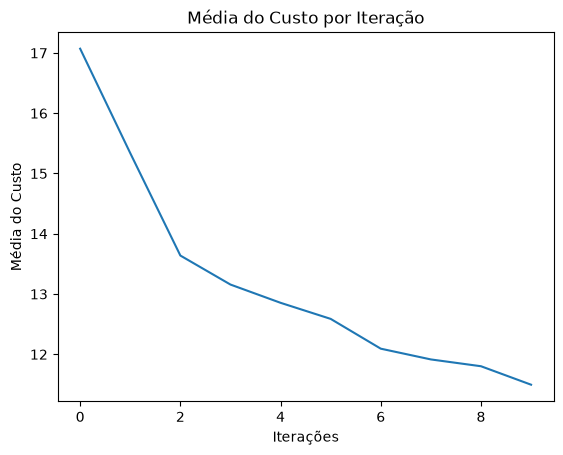

In [214]:
plt.plot(range(N_iteracoes), media)
plt.xlabel('Iterações')
plt.ylabel('Média do Custo')
plt.title('Média do Custo por Iteração')
plt.show()